This is the cleaned publication version of the project notebook. It keeps the original workflow but removes hard-coded local paths.

The notebook performs:
1. Synthetic image generation
2. Colony segmentation using a deterministic dual-mode classical image-processing pipeline
3. Synthetic benchmarking
4. Real assay segmentation
5. Pixel-wise metric calculation
6. ROC analysis
7. Publication figure export

In [ ]:
from pathlib import Path
import csv
import json
import math
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFilter, ImageFont

# Project-relative paths
# Run this notebook from the GitHub repository root. No local Windows paths required.

PROJECT_ROOT = Path.cwd()

SYNTHETIC_DIR = PROJECT_ROOT / "synthetic_data"
SYNTHETIC_IMAGE_DIR = SYNTHETIC_DIR / "images"
SYNTHETIC_MASK_DIR = SYNTHETIC_DIR / "masks"
SYNTHETIC_COORD_DIR = SYNTHETIC_DIR / "colony_data"

EXPERIMENTAL_IMAGE_DIR = PROJECT_ROOT / "experimental_images"
EXPERIMENTAL_MASK_DIR = PROJECT_ROOT / "annotation_masks"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = PROJECT_ROOT / "figures"

# Create output folders if they do not already exist.
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Verify required input folders exist.
for folder in [
    SYNTHETIC_IMAGE_DIR,
    SYNTHETIC_MASK_DIR,
    SYNTHETIC_COORD_DIR,
    EXPERIMENTAL_IMAGE_DIR,
    EXPERIMENTAL_MASK_DIR,
]:
    if not folder.exists():
        raise FileNotFoundError(
            f"Required folder not found: {folder}"
        )

# Edit this list if your experimental filenames are different.
REAL_IMAGE_PAIRS = [
    ("figure_5A", "figure_5A_mask"),
    ("figure_5D", "figure_5D_mask"),
    ("figure_5G", "figure_5G_mask"),
]

# Segmentation parameters used throughout the analysis.
MIN_AREA = 25
MAX_AREA = 5000
MIN_CIRCULARITY = 0.12
USE_WATERSHED = True
SIGMA_BACKGROUND = 31

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

1. Utility functions

These functions are deliverately defined once and reused across synthetic and experimental analysis.

In [3]:
def resolve_with_any_ext(folder: Path, stem: str):
    # Return the first file matching stem with a common image extension.
    folder = Path(folder)
    for ext in (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"):
        path = folder / f"{stem}{ext}"
        if path.exists():
            return path
    return None


def load_bgr_image(folder: Path, stem: str):
    # Load an image as OpenCV BGR and return both image and path.
    path = resolve_with_any_ext(folder, stem)
    if path is None:
        raise FileNotFoundError(f"Could not find image '{stem}.*' in {folder}")
    image = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if image is None:
        raise IOError(f"Could not read image: {path}")
    return image, path


def load_binary_mask(path_or_folder, stem: str | None = None):
    # Load a mask and convert it to a binary uint8 array with values 0 or 1.
    if stem is None:
        path = Path(path_or_folder)
    else:
        path = resolve_with_any_ext(Path(path_or_folder), stem)
        if path is None:
            raise FileNotFoundError(f"Could not find mask '{stem}.*' in {path_or_folder}")

    mask = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if mask is None:
        raise IOError(f"Could not read mask: {path}")
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    return (mask > 0).astype(np.uint8)


def save_binary_mask(path: Path, mask: np.ndarray):
    # Save a binary mask as an 8-bit PNG.
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), (mask > 0).astype(np.uint8) * 255)


def resize_to_match(mask: np.ndarray, reference: np.ndarray):
    # Resize mask to match reference shape using nearest-neighbour interpolation.
    if mask.shape[:2] == reference.shape[:2]:
        return mask
    return cv2.resize(mask.astype(np.uint8), (reference.shape[1], reference.shape[0]), interpolation=cv2.INTER_NEAREST)


def get_font(size=16):
    # Use Arial if available; otherwise fall back to the default PIL font.
    for fp in ["arial.ttf", r"C:\Windows\Fonts\arial.ttf"]:
        try:
            return ImageFont.truetype(fp, size)
        except Exception:
            pass
    return ImageFont.load_default()


2. Synthetic dataset generation

Synthetic images are used because the true colony locations and masks are known. This allows the segmentation algorithm to be benchmarked under controlled image artefacts such as blur, lighting gradients, occlusion, and dense colony overlap.

In [4]:
def save_synthetic_mask(colonies, filename, size=(512, 512)):
    # Create a binary ground-truth mask from known synthetic colony coordinates.
    mask = Image.new("L", size, 0)
    draw = ImageDraw.Draw(mask)
    for x, y, r in colonies:
        draw.ellipse((x - r, y - r, x + r, y + r), fill=255)
    mask.save(SYNTHETIC_MASK_DIR / filename)


def save_synthetic_record(image, colonies, filename):
    # Save a synthetic image, its colony coordinates and its ground-truth mask.
    image.save(SYNTHETIC_IMAGE_DIR / filename)
    with open(SYNTHETIC_COORD_DIR / filename.replace(".png", ".json"), "w") as f:
        json.dump(colonies, f)
    save_synthetic_mask(colonies, filename, size=image.size)


def generate_colony_image(size=(512, 512), count=50, min_r=6, max_r=14):
    # Generate a simple synthetic crystal-violet colony plate image.
    image = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(image)
    colonies = []
    for _ in range(count):
        x = random.randint(max_r, size[0] - max_r)
        y = random.randint(max_r, size[1] - max_r)
        r = random.randint(min_r, max_r)
        stain = random.randint(100, 255)
        draw.ellipse((x - r, y - r, x + r, y + r), fill=(0, 0, stain))
        colonies.append((x, y, r))
    return image, colonies


def apply_blur(image):
    return image.filter(ImageFilter.GaussianBlur(radius=3))


def apply_lighting_gradient(image):
    width, height = image.size
    gradient = Image.new("L", (width, height))
    for x in range(width):
        for y in range(height):
            gradient.putpixel((x, y), int(255 * ((x / width) ** 1.5)))
    return Image.blend(image, gradient.convert("RGB"), alpha=0.5)


def apply_radial_glare(image):
    width, height = image.size
    cx, cy = width // 2, height // 2
    max_dist = (cx**2 + cy**2) ** 0.5
    glare = Image.new("L", image.size, 0)
    for y in range(height):
        for x in range(width):
            dist = ((x - cx)**2 + (y - cy)**2) ** 0.5
            brightness = 255 * ((1 - (dist / max_dist)) ** 2.5)
            glare.putpixel((x, y), int(min(255, max(0, brightness))))
    return Image.blend(image, glare.convert("RGB"), alpha=0.5)


def apply_grid_overlay(image):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for x in range(0, image.width, 50):
        draw.line([(x, 0), (x, image.height)], fill=(150, 150, 150), width=1)
    for y in range(0, image.height, 50):
        draw.line([(0, y), (image.width, y)], fill=(150, 150, 150), width=1)
    return image


def apply_partial_occlusion(image):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for _ in range(5):
        x0 = random.randint(0, image.width - 100)
        y0 = random.randint(0, image.height - 100)
        x1 = x0 + random.randint(30, 100)
        y1 = y0 + random.randint(30, 100)
        draw.rectangle([x0, y0, x1, y1], fill=(180, 180, 180))
    return image


def apply_background_noise(image):
    arr = np.asarray(image)
    noise = np.random.randint(0, 30, arr.shape, dtype="uint8")
    return Image.fromarray(np.clip(arr + noise, 0, 255).astype("uint8"))


def apply_artifacts(image):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for _ in range(3):
        draw.line(
            [random.randint(0, image.width), random.randint(0, image.height),
             random.randint(0, image.width), random.randint(0, image.height)],
            fill=(0, 0, 0), width=2
        )
    draw.text((10, 10), "Label", fill=(0, 0, 0))
    return image


def apply_edge_clipping(image, colonies, size=(512, 512)):
    image = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(image)
    shifted = []
    for x, y, r in colonies:
        x += random.choice([-r * 2, 0, r * 2])
        y += random.choice([-r * 2, 0, r * 2])
        shifted.append((x, y, r))
        draw.ellipse((x - r, y - r, x + r, y + r), fill=(0, 0, random.randint(100, 255)))
    return image, shifted


def apply_inverted_contrast(image):
    return Image.fromarray(255 - np.asarray(image))


def generate_ring_colonies(size=(512, 512), count=50):
    image = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(image)
    colonies = []
    for _ in range(count):
        x = random.randint(20, size[0] - 20)
        y = random.randint(20, size[1] - 20)
        r = random.randint(8, 14)
        stain = random.randint(100, 255)
        draw.ellipse((x - r, y - r, x + r, y + r), fill=(0, 0, stain))
        draw.ellipse((x - r // 2, y - r // 2, x + r // 2, y + r // 2), fill="white")
        colonies.append((x, y, r))
    return image, colonies


def generate_base_complex_image(size=(512, 512), count=80, min_r=4, max_r=20):
    image = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(image)
    colonies = []
    for _ in range(count):
        x = int(random.gauss(mu=size[0] // 2, sigma=100))
        y = int(random.gauss(mu=size[1] // 2, sigma=100))
        x = max(0, min(size[0] - 1, x))
        y = max(0, min(size[1] - 1, y))
        r = random.randint(min_r, max_r)
        stain = random.randint(80, 255)
        draw.ellipse((x - r, y - r, x + r, y + r), fill=(0, 0, stain))
        colonies.append((x, y, r))
    return image, colonies


def generate_density_gradient_image(size=(1024, 512), columns=10):
    image = Image.new("RGB", size, "white")
    draw = ImageDraw.Draw(image)
    colonies = []
    width, height = size
    col_width = width // columns
    for i in range(columns):
        x_min = i * col_width
        x_max = (i + 1) * col_width
        count = 3 * (i + 1) * 5
        for _ in range(count):
            x = random.randint(x_min + 5, x_max - 5)
            y = random.randint(10, height - 10)
            r = random.randint(3, 8)
            stain = random.randint(100, 255)
            draw.ellipse((x - r, y - r, x + r, y + r), fill=(0, 0, stain))
            colonies.append((x, y, r))
    return image, colonies


def generate_synthetic_dataset():
    # Generate the synthetic benchmark dataset used in the manuscript.
    # Clean base image
    image, colonies = generate_colony_image()
    save_synthetic_record(image, colonies, "base_clean.png")

    # Crowded / complex colony image
    image, colonies = generate_base_complex_image()
    save_synthetic_record(image, colonies, "base_complex.png")

    # Single-distortion images
    distortions = {
        "blur.png": apply_blur,
        "lighting_gradient.png": apply_lighting_gradient,
        "radial_glare.png": apply_radial_glare,
        "grid_overlay.png": apply_grid_overlay,
        "partial_occlusion.png": apply_partial_occlusion,
        "background_noise.png": apply_background_noise,
        "artifacts.png": apply_artifacts,
    }
    for filename, distortion_fn in distortions.items():
        image, colonies = generate_colony_image()
        save_synthetic_record(distortion_fn(image), colonies, filename)

    # Edge clipping
    image, colonies = generate_colony_image()
    image, colonies = apply_edge_clipping(image, colonies)
    save_synthetic_record(image, colonies, "edge_clipping.png")

    # Inverted contrast
    image, colonies = generate_colony_image()
    save_synthetic_record(apply_inverted_contrast(image), colonies, "inverted_contrast.png")

    # Ring-shaped colonies
    image, colonies = generate_ring_colonies()
    save_synthetic_record(image, colonies, "ring_colonies.png")

    # Density gradient
    image, colonies = generate_density_gradient_image()
    save_synthetic_record(image, colonies, "density_gradient.png")

    print(f"Synthetic dataset saved to: {SYNTHETIC_DIR}")

# Run this cell to regenerate synthetic images.
generate_synthetic_dataset()


Synthetic dataset saved to: c:\Users\fallo\AppData\Local\Programs\Microsoft VS Code\synthetic_data


3. Dual-mode colony segmentation pipeline

The segmentation method is deterministic and classical rather than machine-learning based. It first searches for blue-stained colony pixels, then falls back to an HSV intensity / saturation mode for images where the blue-contrast assumption fails.

In [5]:
def filter_components(mask: np.ndarray):
    # Remove connected components unlikely to represent colonies.
    # Components are filtered by area and circularity. The retained components are returned as both a binary mask and a list of approximate colony centres / radii.
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    keep = np.zeros_like(mask, dtype=np.uint8)
    colonies = []

    for i in range(1, n):
        x, y, w, h, area = stats[i]
        if area < MIN_AREA or area > MAX_AREA:
            continue

        component = (labels == i).astype(np.uint8)
        contours, _ = cv2.findContours(component, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        contour = contours[0]
        A = cv2.contourArea(contour)
        P = cv2.arcLength(contour, True) + 1e-6
        circularity = 4 * math.pi * A / (P * P)

        if circularity < MIN_CIRCULARITY:
            continue

        keep[labels == i] = 255
        M = cv2.moments(contour)
        cx = int(M["m10"] / (M["m00"] + 1e-6))
        cy = int(M["m01"] / (M["m00"] + 1e-6))
        radius = int(max(3, round((A / np.pi) ** 0.5)))
        colonies.append((cx, cy, radius))

    return keep, colonies


def watershed_split(mask: np.ndarray, guide_bgr: np.ndarray, k=5, threshold_fraction=0.35):
    # Separate touching colonies using distance-transform watershed segmentation.
    if not USE_WATERSHED or mask.max() == 0:
        return mask

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    distance = cv2.distanceTransform(mask.astype(np.uint8), cv2.DIST_L2, 5)
    if distance.max() == 0:
        return mask

    _, sure_fg = cv2.threshold(distance, threshold_fraction * distance.max(), 255, 0)
    sure_fg = sure_fg.astype(np.uint8)
    sure_bg = cv2.dilate(mask.astype(np.uint8), kernel, iterations=2)
    unknown = cv2.subtract(sure_bg, sure_fg)

    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0

    ws = cv2.watershed(guide_bgr.copy(), markers)
    separated = np.zeros_like(mask, dtype=np.uint8)
    for label in np.unique(ws):
        if label > 1:
            separated[ws == label] = 255
    return separated


def compute_blue_contrast_map(image_bgr: np.ndarray):
    # Return the pre-threshold blue-colony contrast map used for segmentation/ROC.
    b, g, r = cv2.split(image_bgr)

    # Crystal-violet colonies appear blue / purple, so the blue channel is enhanced relative to the red and green channels.
    rgmax = cv2.max(r, g)
    diff = cv2.subtract(b, rgmax)

    # Remove smooth illumination variation, glare, and uneven background intensity.
    background = cv2.GaussianBlur(diff, (0, 0), SIGMA_BACKGROUND)
    flat = cv2.subtract(diff, background)
    flat = cv2.normalize(flat, None, 0, 255, cv2.NORM_MINMAX)
    flat = cv2.medianBlur(flat, 3)
    return flat.astype(np.uint8)


def detect_colonies(image_bgr: np.ndarray):
    # Segment colonies from a clonogenic assay image.
    kernel3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

    # Mode 1: blue contrast. This is the main pathway for crystal-violet stained colonies.
    flat = compute_blue_contrast_map(image_bgr)
    _, threshold_blue = cv2.threshold(flat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask_blue = cv2.morphologyEx(threshold_blue, cv2.MORPH_OPEN, kernel3, iterations=1)
    mask_blue = cv2.morphologyEx(mask_blue, cv2.MORPH_CLOSE, kernel3, iterations=1)
    mask_blue = watershed_split(mask_blue, image_bgr, k=5, threshold_fraction=0.35)
    mask1, colonies1 = filter_components(mask_blue)

    if len(colonies1) >= 5:
        return mask1, colonies1, "blue"

    # Mode 2: HSV bright / saturated fallback for unusual or inverted contrast images.
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv)
    V_eq = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(V)
    _, threshold_v = cv2.threshold(V_eq, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    _, threshold_s = cv2.threshold(S, 40, 255, cv2.THRESH_BINARY)
    threshold_hsv = cv2.bitwise_and(threshold_v, threshold_s)
    mask_hsv = cv2.morphologyEx(threshold_hsv, cv2.MORPH_OPEN, kernel3, iterations=1)
    mask_hsv = cv2.morphologyEx(mask_hsv, cv2.MORPH_CLOSE, kernel3, iterations=1)
    mask_hsv = watershed_split(mask_hsv, image_bgr, k=5, threshold_fraction=0.35)
    mask2, colonies2 = filter_components(mask_hsv)

    # Relaxed adaptive threshold if both main modes fail.
    if len(colonies2) < 5:
        threshold_adaptive = cv2.adaptiveThreshold(
            V_eq, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, -3
        )
        threshold_adaptive = cv2.bitwise_and(threshold_adaptive, threshold_s)
        threshold_adaptive = cv2.morphologyEx(threshold_adaptive, cv2.MORPH_OPEN, kernel3, iterations=1)
        threshold_adaptive = cv2.morphologyEx(threshold_adaptive, cv2.MORPH_CLOSE, kernel3, iterations=1)
        threshold_adaptive = watershed_split(threshold_adaptive, image_bgr, k=5, threshold_fraction=0.35)
        mask3, colonies3 = filter_components(threshold_adaptive)
        if len(colonies3) > len(colonies2):
            return mask3, colonies3, "adaptive_hsv"

    return mask2, colonies2, "hsv"


def draw_colony_overlay(image_bgr: np.ndarray, colonies):
    # Draw green colony outlines on a copy of the input image.
    overlay = image_bgr.copy()
    for x, y, radius in colonies:
        cv2.circle(overlay, (int(x), int(y)), int(radius), (0, 255, 0), 2)
    return overlay


def overlay_mask_on_image(image_rgb: np.ndarray, mask_bin: np.ndarray, color=(0, 255, 0), alpha=0.35):
    # Overlay a binary mask onto an RGB image.
    colour = np.zeros_like(image_rgb, dtype=np.uint8)
    colour[mask_bin > 0] = color
    return cv2.addWeighted(image_rgb, 1.0, colour, alpha, 0)


4. Run segmentation on the synthetic dataset

In [6]:
def run_segmentation_on_folder(image_dir: Path, output_dir: Path):
    # Run colony segmentation on every image in a folder.
    output_dir.mkdir(parents=True, exist_ok=True)
    image_paths = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"):
        image_paths.extend(image_dir.glob(ext))
    image_paths = sorted(image_paths)

    if not image_paths:
        raise FileNotFoundError(f"No images found in {image_dir}")

    count_rows = []
    for path in image_paths:
        image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        if image_bgr is None:
            print(f"Skipped unreadable image: {path}")
            continue

        mask, colonies, mode = detect_colonies(image_bgr)
        overlay = draw_colony_overlay(image_bgr, colonies)
        base = path.stem

        save_binary_mask(output_dir / f"{base}_mask.png", mask)
        cv2.imwrite(str(output_dir / f"{base}_overlay_circles.png"), overlay)

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        area_overlay = overlay_mask_on_image(image_rgb, mask > 0, color=(0, 255, 0), alpha=0.35)
        cv2.imwrite(str(output_dir / f"{base}_overlay.png"), cv2.cvtColor(area_overlay, cv2.COLOR_RGB2BGR))

        count_rows.append({"image": base, "pred_count": len(colonies), "mode": mode})

    counts = pd.DataFrame(count_rows)
    counts.to_csv(output_dir / "counts.csv", index=False)
    print(f"Segmented {len(counts)} images. Outputs saved to: {output_dir}")
    return counts

synthetic_counts = run_segmentation_on_folder(SYNTHETIC_IMAGE_DIR, OUTPUT_DIR / "synthetic")
synthetic_counts


Segmented 13 images. Outputs saved to: c:\Users\fallo\AppData\Local\Programs\Microsoft VS Code\outputs\synthetic


,image,pred_count,mode
0,artifacts,41,blue
1,background_noise,31,blue
2,base_clean,42,blue
3,base_complex,39,blue
4,blur,43,blue
5,density_gradient,340,blue
6,edge_clipping,45,blue
7,grid_overlay,39,blue
8,inverted_contrast,45,hsv
9,lighting_gradient,43,blue


5. Pixel-wise evaluation metrics

In [7]:
def pixel_metrics(pred_mask: np.ndarray, gt_mask: np.ndarray):
    # Calculate pixel-wise Dice, IoU, precision and recall.
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)

    TP = np.logical_and(pred, gt).sum()
    FP = np.logical_and(pred, ~gt).sum()
    FN = np.logical_and(~pred, gt).sum()
    TN = np.logical_and(~pred, ~gt).sum()

    dice = 2 * TP / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else np.nan
    iou = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else np.nan
    precision = TP / (TP + FP) if (TP + FP) > 0 else np.nan
    recall = TP / (TP + FN) if (TP + FN) > 0 else np.nan

    return {
        "TP": int(TP), "FP": int(FP), "FN": int(FN), "TN": int(TN),
        "dice": dice, "iou": iou, "precision": precision, "recall": recall,
    }


def error_map_rgb(pred_mask: np.ndarray, gt_mask: np.ndarray):
    # Create RGB error map: TP = green, FP = red, FN = blue.
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    err = np.zeros((*gt.shape, 3), dtype=np.uint8)
    err[np.logical_and(pred, gt)] = (0, 255, 0)
    err[np.logical_and(pred, ~gt)] = (255, 0, 0)
    err[np.logical_and(~pred, gt)] = (0, 102, 255)
    return err


def evaluate_against_masks(image_dir: Path, mask_dir: Path, pred_dir: Path, output_csv: Path):
    # Evaluate predicted masks against reference binary masks.
    rows = []
    panel_dir = pred_dir / "comparison_panels"
    panel_dir.mkdir(parents=True, exist_ok=True)

    for gt_path in sorted(mask_dir.glob("*.png")):
        stem = gt_path.stem
        pred_path = pred_dir / f"{stem}_mask.png"
        image_path = resolve_with_any_ext(image_dir, stem)

        if not pred_path.exists() or image_path is None:
            print(f"Missing prediction or image for {stem}; skipped.")
            continue

        gt = load_binary_mask(gt_path)
        pred = load_binary_mask(pred_path)
        pred = resize_to_match(pred, gt)
        metrics = pixel_metrics(pred, gt)

        # Save per-image comparison panel.
        image_bgr = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        err = error_map_rgb(pred, gt)

        fig, axes = plt.subplots(1, 4, figsize=(12, 3))
        axes[0].imshow(image_rgb); axes[0].set_title("Original")
        axes[1].imshow(gt, cmap="gray"); axes[1].set_title("Manual mask")
        axes[2].imshow(pred, cmap="gray"); axes[2].set_title("Predicted mask")
        axes[3].imshow(err); axes[3].set_title("TP / FP / FN")
        for ax in axes:
            ax.axis("off")
        fig.tight_layout()
        panel_path = panel_dir / f"{stem}_comparison.png"
        fig.savefig(panel_path, dpi=300, bbox_inches="tight")
        plt.close(fig)

        metrics.update({"image": stem, "panel_path": str(panel_path)})
        rows.append(metrics)

    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    print(f"Saved metrics to: {output_csv}")
    return df

synthetic_metrics = evaluate_against_masks(
    SYNTHETIC_IMAGE_DIR,
    SYNTHETIC_MASK_DIR,
    OUTPUT_DIR / "synthetic",
    OUTPUT_DIR / "synthetic" / "synthetic_pixel_metrics.csv",
)
synthetic_metrics


Saved metrics to: c:\Users\fallo\AppData\Local\Programs\Microsoft VS Code\outputs\synthetic\synthetic_pixel_metrics.csv


,TP,FP,FN,TN,dice,iou,precision,recall,image,panel_path
0,14637,6,2615,244886,0.917824,0.848128,0.999590,0.848423,artifacts,c:\Users\fallo\AppData\Local\Programs\Microsof...
1,12612,64,5379,244089,0.822513,0.698532,0.994951,0.701017,background_noise,c:\Users\fallo\AppData\Local\Programs\Microsof...
2,14415,2,3145,244582,0.901586,0.820806,0.999861,0.820900,base_clean,c:\Users\fallo\AppData\Local\Programs\Microsof...
3,24569,7,14512,223056,0.771918,0.628556,0.999715,0.628669,base_complex,c:\Users\fallo\AppData\Local\Programs\Microsof...
4,13105,76,5069,243894,0.835911,0.718082,0.994234,0.721085,blur,c:\Users\fallo\AppData\Local\Programs\Microsof...
5,70175,468,18128,435517,0.883004,0.790517,0.993375,0.794707,density_gradient,c:\Users\fallo\AppData\Local\Programs\Microsof...
6,15613,10,2843,243678,0.916283,0.845500,0.999360,0.845958,edge_clipping,c:\Users\fallo\AppData\Local\Programs\Microsof...
7,14454,3,2779,244908,0.912212,0.838594,0.999792,0.838740,grid_overlay,c:\Users\fallo\AppData\Local\Programs\Microsof...
8,17045,13,2713,242373,0.925956,0.862121,0.999238,0.862689,inverted_contrast,c:\Users\fallo\AppData\Local\Programs\Microsof...
9,16033,7,2633,243471,0.923932,0.858619,0.999564,0.858941,lighting_gradient,c:\Users\fallo\AppData\Local\Programs\Microsof...


6. Synthetic summary figure

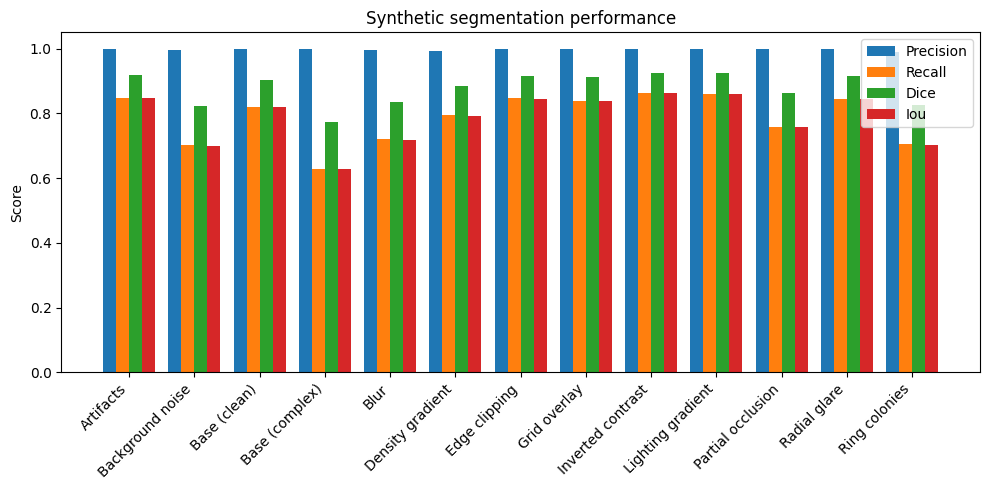

Saved: c:\Users\fallo\AppData\Local\Programs\Microsoft VS Code\figures\Figure2_SyntheticMetrics.png


In [8]:
def condition_label(stem: str):
    labels = {
        "base_clean": "Base (clean)",
        "base_complex": "Base (complex)",
        "artifacts": "Artifacts",
        "background_noise": "Background noise",
        "blur": "Blur",
        "concentric_rings": "Concentric rings",
        "edge_clipping": "Edge clipping",
        "inverted_contrast": "Inverted contrast",
        "lighting_gradient": "Lighting gradient",
        "partial_occlusion": "Partial occlusion",
        "radial_glare": "Radial glare",
        "ring_colonies": "Ring colonies",
        "grid_overlay": "Grid overlay",
        "density_gradient": "Density gradient",
    }
    return labels.get(stem, stem.replace("_", " ").title())


def plot_synthetic_metric_summary(metrics_df: pd.DataFrame):
    """Plot per-condition Dice, IoU, precision and recall."""
    df = metrics_df.copy()
    df["condition"] = df["image"].map(condition_label)
    metrics = ["precision", "recall", "dice", "iou"]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df))
    width = 0.2
    for i, metric in enumerate(metrics):
        ax.bar(x + (i - 1.5) * width, df[metric], width, label=metric.capitalize())

    ax.set_xticks(x)
    ax.set_xticklabels(df["condition"], rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title("Synthetic segmentation performance")
    ax.legend()
    fig.tight_layout()
    out = FIGURE_DIR / "Figure2_SyntheticMetrics.png"
    fig.savefig(out, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

plot_synthetic_metric_summary(synthetic_metrics)

7. ROC analysis

ROC analysis is performed using the continuous pre-threshold blue-contrast map rather than the final binary segmentation. This tests intrinsic colony-background separability independently of the chosen threshold.

C:\Users\fallo\AppData\Local\Temp\ipykernel_28424\959210922.py:18: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_value = float(np.trapz(tpr, fpr))


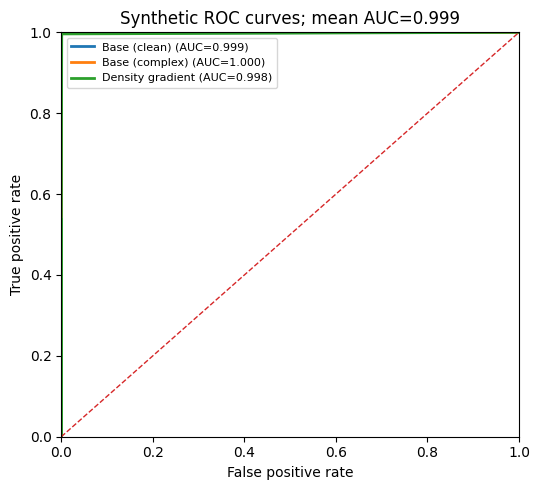

Saved: c:\Users\fallo\AppData\Local\Programs\Microsoft VS Code\figures\Figure4_SyntheticROC.png


In [9]:
def roc_from_score_map(score_u8: np.ndarray, gt_mask: np.ndarray):
    # Sweep thresholds over a score map and return ROC data.
    gt = gt_mask.astype(bool)
    tpr, fpr, thresholds = [], [], []
    P = gt.sum()
    N = (~gt).sum()
    for thr in range(256):
        pred = score_u8 >= thr
        TP = np.logical_and(pred, gt).sum()
        FP = np.logical_and(pred, ~gt).sum()
        tpr.append(TP / (P + 1e-8))
        fpr.append(FP / (N + 1e-8))
        thresholds.append(thr)
    order = np.argsort(fpr)
    fpr = np.asarray(fpr)[order]
    tpr = np.asarray(tpr)[order]
    thresholds = np.asarray(thresholds)[order]
    auc_value = float(np.trapz(tpr, fpr))
    return pd.DataFrame({"threshold": thresholds, "FPR": fpr, "TPR": tpr}), auc_value


def plot_synthetic_roc(stems=("base_clean", "base_complex", "density_gradient")):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    aucs = []
    for stem in stems:
        image_bgr, _ = load_bgr_image(SYNTHETIC_IMAGE_DIR, stem)
        gt = load_binary_mask(SYNTHETIC_MASK_DIR, stem)
        score = compute_blue_contrast_map(image_bgr)
        if score.shape != gt.shape:
            score = cv2.resize(score, (gt.shape[1], gt.shape[0]), interpolation=cv2.INTER_LINEAR)
        roc_df, auc_value = roc_from_score_map(score, gt)
        aucs.append(auc_value)
        roc_df.to_csv(OUTPUT_DIR / "synthetic" / f"{stem}_roc_sweep.csv", index=False)
        ax.plot(roc_df["FPR"], roc_df["TPR"], lw=2, label=f"{condition_label(stem)} (AUC={auc_value:.3f})")

    ax.plot([0, 1], [0, 1], "--", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"Synthetic ROC curves; mean AUC={np.mean(aucs):.3f}")
    ax.legend(fontsize=8)
    fig.tight_layout()
    out = FIGURE_DIR / "Figure4_SyntheticROC.png"
    fig.savefig(out, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

plot_synthetic_roc()


8. Run segmentation on experimental clonogenic assay images

In [10]:
def run_experimental_segmentation():
    image_paths = []
    for ext in ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp"):
        image_paths.extend(EXPERIMENTAL_IMAGE_DIR.glob(ext))
    image_paths = sorted(image_paths)

    if not image_paths:
        print(f"No experimental images found in {EXPERIMENTAL_IMAGE_DIR}. Add images and rerun this cell.")
        return pd.DataFrame()

    out_dir = OUTPUT_DIR / "experimental"
    rows = []
    for path in image_paths:
        image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
        mask, colonies, mode = detect_colonies(image_bgr)
        base = path.stem

        save_binary_mask(out_dir / f"{base}_mask.png", mask)
        cv2.imwrite(str(out_dir / f"{base}_overlay_circles.png"), draw_colony_overlay(image_bgr, colonies))

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        overlay = overlay_mask_on_image(image_rgb, mask > 0, color=(0, 255, 0), alpha=0.35)
        cv2.imwrite(str(out_dir / f"{base}_overlay.png"), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

        rows.append({"image": base, "pred_count": len(colonies), "mode": mode})

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / "experimental_counts.csv", index=False)
    print(f"Experimental outputs saved to: {out_dir}")
    return df

experimental_counts = run_experimental_segmentation()
experimental_counts


No experimental images found in c:\Users\fallo\AppData\Local\Programs\Microsoft VS Code\experimental_images. Add images and rerun this cell.


""


9. Experimental image metrics and Figure 5. panel

In [11]:
def compute_error_overlay(image_rgb, pred_bin, gt_bin, alpha=0.35):
    # Overlay TP/FP/FN segmentation errors on the original image.
    pred = pred_bin.astype(bool)
    gt = gt_bin.astype(bool)
    err = np.zeros_like(image_rgb)
    err[np.logical_and(pred, gt)] = (0, 255, 0)       # TP: green
    err[np.logical_and(pred, ~gt)] = (255, 0, 0)      # FP: red
    err[np.logical_and(~pred, gt)] = (0, 102, 255)    # FN: blue
    return cv2.addWeighted(image_rgb, 1.0, err, alpha, 0)


def evaluate_experimental_images():
    out_dir = OUTPUT_DIR / "experimental"
    rows = []

    for image_stem, mask_stem in REAL_IMAGE_PAIRS:
        image_path = resolve_with_any_ext(EXPERIMENTAL_IMAGE_DIR, image_stem)
        gt_path = resolve_with_any_ext(EXPERIMENTAL_MASK_DIR, mask_stem)
        pred_path = out_dir / f"{image_stem}_mask.png"

        if image_path is None or gt_path is None or not pred_path.exists():
            print(f"Missing image, mask or prediction for {image_stem}; skipped.")
            continue

        image_bgr = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        gt = load_binary_mask(gt_path)
        pred = load_binary_mask(pred_path)
        pred = resize_to_match(pred, gt)
        metrics = pixel_metrics(pred, gt)
        metrics.update({"image": image_stem, "GT_pixels": int(gt.sum()), "Pred_pixels": int(pred.sum())})
        rows.append(metrics)

    df = pd.DataFrame(rows)
    if not df.empty:
        df.to_csv(out_dir / "experimental_pixel_metrics.csv", index=False)
        print(df[["image", "dice", "iou", "precision", "recall"]])
    return df

experimental_metrics = evaluate_experimental_images()
experimental_metrics


Missing image, mask or prediction for clonogenic_real_1; skipped.
Missing image, mask or prediction for clonogenic_real_2; skipped.
Missing image, mask or prediction for clonogenic_real_4; skipped.


""


In [12]:
def make_experimental_panel():
    # Create a figure panel: original, GT mask, prediction, error overlay.
    out_dir = OUTPUT_DIR / "experimental"
    valid_rows = []
    for image_stem, mask_stem in REAL_IMAGE_PAIRS:
        image_path = resolve_with_any_ext(EXPERIMENTAL_IMAGE_DIR, image_stem)
        gt_path = resolve_with_any_ext(EXPERIMENTAL_MASK_DIR, mask_stem)
        pred_path = out_dir / f"{image_stem}_mask.png"
        if image_path is not None and gt_path is not None and pred_path.exists():
            valid_rows.append((image_stem, mask_stem, image_path, gt_path, pred_path))

    if not valid_rows:
        print("No complete experimental image/mask/prediction triplets available for panel generation.")
        return

    headers = ["Original image", "Manual ground truth", "Automated segmentation", "Error overlay"]
    fig, axes = plt.subplots(len(valid_rows), len(headers), figsize=(7.2, 2.0 * len(valid_rows)))
    if len(valid_rows) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (image_stem, mask_stem, image_path, gt_path, pred_path) in enumerate(valid_rows):
        image_bgr = cv2.imread(str(image_path))
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        gt = load_binary_mask(gt_path)
        pred = load_binary_mask(pred_path)
        pred = resize_to_match(pred, gt)
        overlay = compute_error_overlay(image_rgb, pred, gt)

        images = [image_rgb, gt, pred, overlay]
        cmaps = [None, "gray", "gray", None]
        for col_idx, item in enumerate(images):
            ax = axes[row_idx, col_idx]
            ax.imshow(item, cmap=cmaps[col_idx])
            ax.axis("off")
            if row_idx == 0:
                ax.set_title(headers[col_idx], fontsize=9)

    fig.tight_layout(pad=0.2)
    out = FIGURE_DIR / "Figure5_ExperimentalAssays.png"
    fig.savefig(out, dpi=600, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    print(f"Saved: {out}")

make_experimental_panel()


No complete experimental image/mask/prediction triplets available for panel generation.


10. Experimental ROC analysis

In [13]:
def plot_experimental_roc():
    out_dir = OUTPUT_DIR / "experimental"
    fig, ax = plt.subplots(figsize=(5.5, 5))
    aucs = []

    for image_stem, mask_stem in REAL_IMAGE_PAIRS:
        image_path = resolve_with_any_ext(EXPERIMENTAL_IMAGE_DIR, image_stem)
        gt_path = resolve_with_any_ext(EXPERIMENTAL_MASK_DIR, mask_stem)
        if image_path is None or gt_path is None:
            print(f"Missing image or mask for {image_stem}; skipped.")
            continue

        image_bgr = cv2.imread(str(image_path))
        gt = load_binary_mask(gt_path)
        score = compute_blue_contrast_map(image_bgr)
        score = resize_to_match(score, gt)

        roc_df, auc_value = roc_from_score_map(score, gt)
        aucs.append(auc_value)
        roc_df.to_csv(out_dir / f"{image_stem}_roc_sweep.csv", index=False)
        ax.plot(roc_df["FPR"], roc_df["TPR"], lw=2, label=f"{image_stem} (AUC={auc_value:.3f})")

    if not aucs:
        print("No experimental ROC curves generated; add experimental images and masks first.")
        plt.close(fig)
        return

    ax.plot([0, 1], [0, 1], "--", lw=1)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("False positive rate (1 - specificity)")
    ax.set_ylabel("True positive rate (recall)")
    ax.set_title(f"Experimental pixel-wise ROC; macro AUC={np.mean(aucs):.3f}")
    ax.legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    out = FIGURE_DIR / "Figure4_ExperimentalROC.png"
    fig.savefig(out, dpi=600, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out}")

plot_experimental_roc()

Missing image or mask for clonogenic_real_1; skipped.
Missing image or mask for clonogenic_real_2; skipped.
Missing image or mask for clonogenic_real_4; skipped.
No experimental ROC curves generated; add experimental images and masks first.


11. Notes

- The notebook can be run without experimental images. synthetic analysis will still run
- To reproduce experimental validation, add real assay images to 'experimental_images/' and the corresponding manual ImageJ masks to 'annotation_masks/'
- Outputs are written to 'outputs/'; publication figures are written to 'figures/'